# Notebook 00: Load & Impute Real SRK Allele Data

This notebook loads real SRK (S-locus Receptor Kinase) genotyping data for **slickspot peppergrass** (*Lepidium papilliferum*), performs exploratory data analysis, and imputes tetraploid genotypes from variable-depth sequencing data.

## Data Sources

- `data/SRK_individual_genotypes.tsv` — binary presence/absence matrix (119 individuals x 172 alleles)
- `data/SRK_individual_allele_table.tsv` — long-format read-level data (each row = one read mapping to an allele for an individual)

---
## IMPUTATION WARNING

**Most individuals do NOT have exactly 4 detected alleles.** Since *L. papilliferum* is tetraploid (4 allele copies per individual), we must impute genotypes from incomplete data. Only 6 of 119 individuals have exactly 4 detected alleles.

### Imputation Rules

| Detected alleles | Rule | Example |
|---|---|---|
| 1 | Homozygous: (A,A,A,A) | 1 allele, any reads -> 4 copies |
| 2 | Proportional to read counts, fill 4 slots | A(6) B(2) -> (A,A,A,B) |
| 3 | Proportional to read counts, fill 4 slots | A(5) B(2) C(1) -> (A,A,B,C) |
| 4 | Direct: one copy each | A,B,C,D -> (A,B,C,D) regardless of reads |
| >4 | **Strategy A:** top 4 by reads, proportional fill | Drops lowest-read alleles |
| >4 | **Strategy B:** top 3 fixed, rotate 4th through remaining | Creates multiple genotype entries |

### Slot Allocation Method

**Largest remainder method**: Multiply each allele's read proportion by 4, floor each value, then distribute remaining slots to alleles with the largest fractional remainders. Ties broken alphabetically (by allele name). For exactly 4 detected alleles, skip proportional allocation and assign 1 copy each.

**All downstream results depend on these imputed genotypes.** Interpret with caution.

---

In [1]:
import os
import pickle
from collections import Counter
from math import floor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)

DATA_DIR = os.path.join("..", "data")
print("Imports loaded.")

Imports loaded.


## 1. Load Raw Data

In [2]:
# Load both TSV files
genotypes_df = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_genotypes.tsv"), sep="\t")
allele_table = pd.read_csv(os.path.join(DATA_DIR, "SRK_individual_allele_table.tsv"), sep="\t")

# Extract individual names and allele columns from the genotypes matrix
individuals_geno = sorted(genotypes_df["Individual"].tolist())
allele_columns = [c for c in genotypes_df.columns if c != "Individual"]

# Extract individual names from the allele table
individuals_reads = sorted(allele_table["Individual"].unique().tolist())

print(f"Genotypes matrix: {genotypes_df.shape[0]} individuals x {len(allele_columns)} alleles")
print(f"Allele table: {len(allele_table)} read rows, {len(individuals_reads)} individuals")

# Validate: same set of individuals in both files
assert set(individuals_geno) == set(individuals_reads), (
    f"Individual mismatch! "
    f"Only in genotypes: {set(individuals_geno) - set(individuals_reads)}, "
    f"Only in reads: {set(individuals_reads) - set(individuals_geno)}"
)
print(f"Validated: same {len(individuals_geno)} individuals in both files.")

# Validate: all genotype matrix values are 0 or 1
geno_values = genotypes_df[allele_columns].values
assert set(np.unique(geno_values)) <= {0, 1}, "Genotype matrix contains values other than 0/1!"
print("Validated: all genotype matrix values are 0 or 1.")

# Cross-validate: alleles with reads should match 1s in genotype matrix
mismatches = 0
for _, row in allele_table.iterrows():
    ind = row["Individual"]
    allele = row["Allele"]
    geno_row = genotypes_df[genotypes_df["Individual"] == ind]
    if allele in allele_columns:
        val = geno_row[allele].values[0]
        if val != 1:
            mismatches += 1

if mismatches == 0:
    print("Validated: all read alleles match genotype matrix 1s.")
else:
    print(f"WARNING: {mismatches} read-allele entries don't match genotype matrix!")

Genotypes matrix: 119 individuals x 172 alleles
Allele table: 648 read rows, 119 individuals
Validated: same 119 individuals in both files.
Validated: all genotype matrix values are 0 or 1.


Validated: all read alleles match genotype matrix 1s.


## 2. EDA: Alleles Per Individual

How many distinct alleles were detected per individual? For a tetraploid, we expect up to 4 unique alleles, but sequencing depth and sensitivity limitations mean many individuals have fewer (or more, due to potential artifacts).

Detected alleles per individual:
   Alleles    Count        %
----------------------------
         1       35    29.4%
         2       53    44.5%
         3       19    16.0%
         4        6     5.0%
         5        4     3.4%
         6        1     0.8%
         7        1     0.8%

Individuals with exactly 4 alleles: 6 / 119


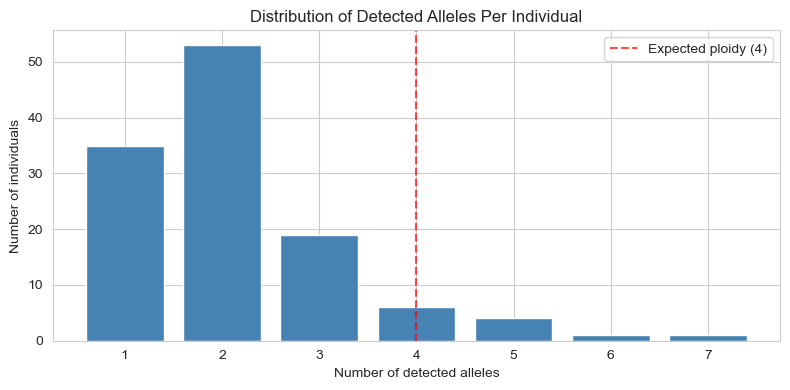

In [3]:
# Count detected alleles per individual from the genotype matrix
alleles_per_ind = genotypes_df.set_index("Individual")[allele_columns].sum(axis=1).astype(int)
alleles_per_ind.name = "n_alleles"

# Breakdown table
breakdown = alleles_per_ind.value_counts().sort_index()
print("Detected alleles per individual:")
print(f"{'Alleles':>10} {'Count':>8} {'%':>8}")
print("-" * 28)
for n_alleles, count in breakdown.items():
    pct = 100 * count / len(alleles_per_ind)
    print(f"{n_alleles:>10} {count:>8} {pct:>7.1f}%")

print(f"\nIndividuals with exactly 4 alleles: {breakdown.get(4, 0)} / {len(alleles_per_ind)}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(breakdown.index, breakdown.values, color="steelblue", edgecolor="white")
ax.axvline(x=4, color="red", linestyle="--", alpha=0.7, label="Expected ploidy (4)")
ax.set_xlabel("Number of detected alleles")
ax.set_ylabel("Number of individuals")
ax.set_title("Distribution of Detected Alleles Per Individual")
ax.legend()
ax.set_xticks(breakdown.index)
plt.tight_layout()
plt.show()

## 3. EDA: Allele Prevalence

How many individuals carry each allele? Many alleles may be singletons (found in only 1 individual).

Total distinct alleles: 172
Singletons (in only 1 individual): 126 (73.3%)
Alleles in 2+ individuals: 46

Top 10 most common alleles:
  Allele_97: 12 individuals
  Allele_122: 7 individuals
  Allele_47: 6 individuals
  Allele_119: 4 individuals
  Allele_15: 4 individuals
  Allele_39: 4 individuals
  Allele_107: 4 individuals
  Allele_54: 3 individuals
  Allele_25: 3 individuals
  Allele_26: 3 individuals


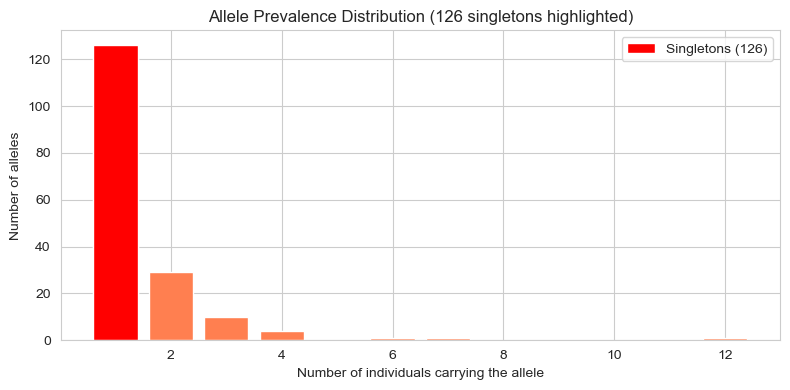

In [4]:
# Count how many individuals carry each allele (from genotype matrix)
allele_prevalence = genotypes_df[allele_columns].sum(axis=0).astype(int).sort_values(ascending=False)

n_singletons = (allele_prevalence == 1).sum()
n_total_alleles = len(allele_prevalence)

print(f"Total distinct alleles: {n_total_alleles}")
print(f"Singletons (in only 1 individual): {n_singletons} ({100*n_singletons/n_total_alleles:.1f}%)")
print(f"Alleles in 2+ individuals: {n_total_alleles - n_singletons}")
print(f"\nTop 10 most common alleles:")
for allele, count in allele_prevalence.head(10).items():
    print(f"  {allele}: {count} individuals")

# Histogram of allele prevalence
fig, ax = plt.subplots(figsize=(8, 4))
prev_counts = allele_prevalence.value_counts().sort_index()
ax.bar(prev_counts.index, prev_counts.values, color="coral", edgecolor="white")
ax.set_xlabel("Number of individuals carrying the allele")
ax.set_ylabel("Number of alleles")
ax.set_title(f"Allele Prevalence Distribution ({n_singletons} singletons highlighted)")
# Highlight singletons
if 1 in prev_counts.index:
    ax.bar([1], [prev_counts[1]], color="red", edgecolor="white", label=f"Singletons ({n_singletons})")
    ax.legend()
plt.tight_layout()
plt.show()

## 4. EDA: Read Depth

Read depth per individual and per allele-call. Low-depth calls are less reliable.

Total read rows: 648
Reads per individual: min=1, median=5, max=17, mean=5.4

Reads per allele call: min=1, median=2, max=10
Single-read allele calls: 89 / 255 (34.9%)


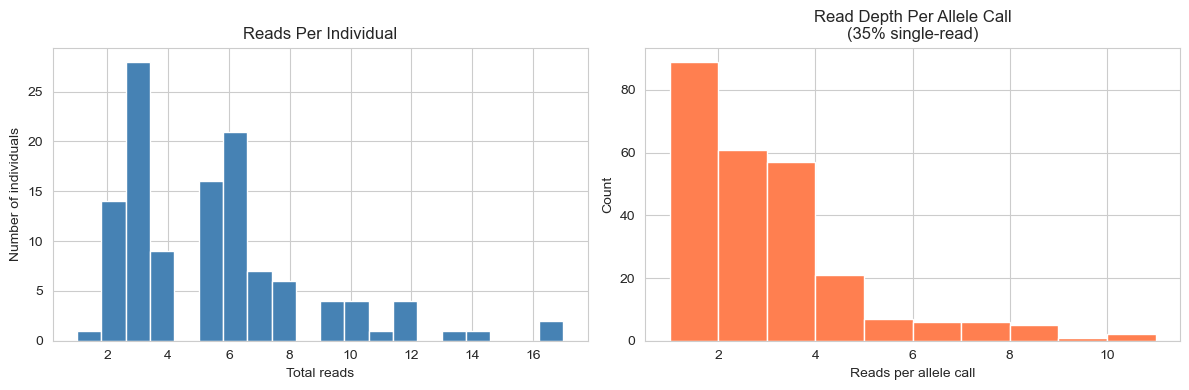

In [5]:
# Read counts per individual
reads_per_ind = allele_table.groupby("Individual").size()
reads_per_ind.name = "total_reads"

# Read counts per (individual, allele) pair
reads_per_allele_call = allele_table.groupby(["Individual", "Allele"]).size()
reads_per_allele_call.name = "reads"

n_single_read = (reads_per_allele_call == 1).sum()
n_total_calls = len(reads_per_allele_call)

print(f"Total read rows: {len(allele_table)}")
print(f"Reads per individual: min={reads_per_ind.min()}, median={reads_per_ind.median():.0f}, "
      f"max={reads_per_ind.max()}, mean={reads_per_ind.mean():.1f}")
print(f"\nReads per allele call: min={reads_per_allele_call.min()}, "
      f"median={reads_per_allele_call.median():.0f}, max={reads_per_allele_call.max()}")
print(f"Single-read allele calls: {n_single_read} / {n_total_calls} ({100*n_single_read/n_total_calls:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reads_per_ind.values, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Total reads")
axes[0].set_ylabel("Number of individuals")
axes[0].set_title("Reads Per Individual")

axes[1].hist(reads_per_allele_call.values, bins=range(1, reads_per_allele_call.max() + 2),
             color="coral", edgecolor="white")
axes[1].set_xlabel("Reads per allele call")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Read Depth Per Allele Call\n({100*n_single_read/n_total_calls:.0f}% single-read)")

plt.tight_layout()
plt.show()

## 5. EDA: Population Groups

Individuals are named by library and barcode (e.g., `Library001_barcode01`). Parse library membership to identify population groups.

In [6]:
# Parse population group from individual name
def get_population_group(name):
    """Extract library/population group from individual name."""
    if name.startswith("Library"):
        return name.split("_")[0]  # e.g., "Library001"
    return "Other"  # e.g., "BEA_hybrid"

pop_groups = pd.Series(
    {ind: get_population_group(ind) for ind in individuals_geno}
).sort_index()
pop_groups.name = "group"

group_counts = pop_groups.value_counts().sort_index()
print("Population groups:")
for group, count in group_counts.items():
    print(f"  {group}: {count} individuals")
print(f"  Total: {group_counts.sum()}")

Population groups:
  Library001: 21 individuals
  Library002: 34 individuals
  Library003: 18 individuals
  Library004: 11 individuals
  Library005: 34 individuals
  Other: 1 individuals
  Total: 119


## 6. Allele Name-to-Integer Mapping

Map allele names (e.g., `Allele_130`) to integer IDs for computational efficiency, consistent with the project convention of integer allele IDs.

In [7]:
# Sort allele names alphabetically and assign integer IDs 1..N
sorted_allele_names = sorted(allele_columns)
name_to_id = {name: i + 1 for i, name in enumerate(sorted_allele_names)}
id_to_name = {v: k for k, v in name_to_id.items()}

allele_pool = sorted(name_to_id.values())  # [1, 2, ..., 172]

print(f"Allele pool: {len(allele_pool)} alleles (IDs {allele_pool[0]} to {allele_pool[-1]})")
print(f"\nFirst 10 mappings:")
for name in sorted_allele_names[:10]:
    print(f"  {name} -> {name_to_id[name]}")
print(f"\nLast 5 mappings:")
for name in sorted_allele_names[-5:]:
    print(f"  {name} -> {name_to_id[name]}")

Allele pool: 172 alleles (IDs 1 to 172)

First 10 mappings:
  Allele_01 -> 1
  Allele_05 -> 2
  Allele_06 -> 3
  Allele_07 -> 4
  Allele_08 -> 5
  Allele_10 -> 6
  Allele_101 -> 7
  Allele_103 -> 8
  Allele_105 -> 9
  Allele_106 -> 10

Last 5 mappings:
  Allele_81 -> 168
  Allele_82 -> 169
  Allele_85 -> 170
  Allele_86 -> 171
  Allele_97 -> 172


## 7. Imputation Functions

### Largest Remainder Method

Given alleles with read counts, allocate exactly 4 slots proportional to read frequencies:
1. Compute each allele's proportion of total reads
2. Multiply by 4 to get ideal (fractional) slot counts
3. Floor each to get guaranteed slots
4. Distribute remaining slots to alleles with the largest fractional remainders
5. Break ties alphabetically (by allele name)

In [8]:
def largest_remainder_allocate(allele_reads, total_slots=4):
    """Allocate slots to alleles proportional to read counts using largest remainder method.

    Parameters
    ----------
    allele_reads : dict[str, int]
        Mapping from allele name to read count.
    total_slots : int
        Total slots to fill (default 4 for tetraploid).

    Returns
    -------
    dict[str, int]
        Mapping from allele name to number of allocated slots.
    """
    total_reads = sum(allele_reads.values())
    if total_reads == 0:
        raise ValueError("No reads to allocate from")

    # Compute ideal fractional slots
    ideal = {a: (count / total_reads) * total_slots for a, count in allele_reads.items()}

    # Floor each to get guaranteed slots
    floored = {a: floor(v) for a, v in ideal.items()}
    remainders = {a: ideal[a] - floored[a] for a in ideal}

    # How many slots still to distribute
    allocated = sum(floored.values())
    remaining = total_slots - allocated

    # Distribute remaining slots by largest remainder, ties broken alphabetically
    sorted_by_remainder = sorted(remainders.keys(), key=lambda a: (-remainders[a], a))
    for i in range(remaining):
        floored[sorted_by_remainder[i]] += 1

    return floored


def impute_genotype(individual, allele_reads, strategy="A"):
    """Impute a tetraploid genotype from detected alleles and read counts.

    Parameters
    ----------
    individual : str
        Individual name.
    allele_reads : dict[str, int]
        Mapping from allele name to read count.
    strategy : str
        Strategy for >4 alleles: 'A' (top 4 proportional) or 'B' (top 3 + rotate).

    Returns
    -------
    list[tuple[int, ...]]
        One or more imputed genotypes (sorted tuples of integer allele IDs).
    dict
        Metadata: detected_count, read_counts, imputation_rule, confidence.
    """
    n_detected = len(allele_reads)
    total_reads = sum(allele_reads.values())

    metadata = {
        "individual": individual,
        "detected_count": n_detected,
        "total_reads": total_reads,
        "read_counts": dict(allele_reads),
    }

    if n_detected == 0:
        raise ValueError(f"No alleles detected for {individual}")

    if n_detected == 1:
        # Homozygous: all 4 copies of the single allele
        allele_name = list(allele_reads.keys())[0]
        aid = name_to_id[allele_name]
        genotype = tuple([aid] * 4)
        metadata["imputation_rule"] = "homozygous_4x"
        metadata["confidence"] = "low"
        return [genotype], metadata

    if n_detected == 2:
        # Proportional fill of 4 slots from 2 alleles
        allocation = largest_remainder_allocate(allele_reads, 4)
        alleles = []
        for allele_name in sorted(allocation.keys()):
            alleles.extend([name_to_id[allele_name]] * allocation[allele_name])
        genotype = tuple(sorted(alleles))
        metadata["imputation_rule"] = "proportional_2alleles"
        metadata["confidence"] = "low"
        return [genotype], metadata

    if n_detected == 3:
        # Proportional fill of 4 slots from 3 alleles
        allocation = largest_remainder_allocate(allele_reads, 4)
        alleles = []
        for allele_name in sorted(allocation.keys()):
            alleles.extend([name_to_id[allele_name]] * allocation[allele_name])
        genotype = tuple(sorted(alleles))
        metadata["imputation_rule"] = "proportional_3alleles"
        metadata["confidence"] = "medium"
        return [genotype], metadata

    if n_detected == 4:
        # Direct assignment: one copy each
        alleles = sorted([name_to_id[a] for a in allele_reads.keys()])
        genotype = tuple(alleles)
        metadata["imputation_rule"] = "direct_4alleles"
        metadata["confidence"] = "high"
        return [genotype], metadata

    # >4 detected alleles
    sorted_alleles = sorted(allele_reads.keys(), key=lambda a: (-allele_reads[a], a))

    if strategy == "A":
        # Top 4 by reads, proportional fill
        top4 = sorted_alleles[:4]
        top4_reads = {a: allele_reads[a] for a in top4}
        allocation = largest_remainder_allocate(top4_reads, 4)
        alleles = []
        for allele_name in sorted(allocation.keys()):
            alleles.extend([name_to_id[allele_name]] * allocation[allele_name])
        genotype = tuple(sorted(alleles))
        metadata["imputation_rule"] = "top4_proportional"
        metadata["confidence"] = "low"
        metadata["dropped_alleles"] = sorted_alleles[4:]
        return [genotype], metadata

    elif strategy == "B":
        # Top 3 fixed, rotate 4th through remaining
        top3 = sorted_alleles[:3]
        remaining = sorted_alleles[3:]
        top3_ids = sorted([name_to_id[a] for a in top3])
        genotypes = []
        for extra_allele in remaining:
            extra_id = name_to_id[extra_allele]
            genotype = tuple(sorted(top3_ids + [extra_id]))
            genotypes.append(genotype)
        metadata["imputation_rule"] = "top3_rotate"
        metadata["confidence"] = "low"
        metadata["n_variants"] = len(genotypes)
        return genotypes, metadata

    else:
        raise ValueError(f"Unknown strategy: {strategy}")


print("Imputation functions defined: largest_remainder_allocate, impute_genotype")

Imputation functions defined: largest_remainder_allocate, impute_genotype


## 8. Run Imputation (Strategy A)

Apply imputation to all 119 individuals using **Strategy A** (top 4 alleles by read count, proportional fill) as the default.

In [9]:
# Build read counts per (individual, allele) from allele table
read_counts = allele_table.groupby(["Individual", "Allele"]).size().reset_index(name="reads")

# Impute genotypes for all individuals
population_real = []  # List of (individual_name, genotype_tuple)
individual_metadata = []

for ind in sorted(individuals_geno):
    # Get read counts for this individual
    ind_reads = read_counts[read_counts["Individual"] == ind]
    allele_reads = dict(zip(ind_reads["Allele"], ind_reads["reads"]))

    genotypes, meta = impute_genotype(ind, allele_reads, strategy="A")

    for g in genotypes:
        population_real.append((ind, g))

    individual_metadata.append(meta)

# Build population as list of genotype tuples (the format used by all other notebooks)
population_genotypes = [g for _, g in population_real]
individual_names = [n for n, _ in population_real]

meta_df = pd.DataFrame(individual_metadata)

print(f"Imputed {len(population_genotypes)} genotypes from {len(individuals_geno)} individuals")
print(f"\nImputation rule breakdown:")
print(meta_df["imputation_rule"].value_counts().to_string())
print(f"\nConfidence breakdown:")
print(meta_df["confidence"].value_counts().to_string())

Imputed 119 genotypes from 119 individuals

Imputation rule breakdown:
imputation_rule
proportional_2alleles    53
homozygous_4x            35
proportional_3alleles    19
top4_proportional         6
direct_4alleles           6

Confidence breakdown:
confidence
low       94
medium    19
high       6


## 9. Validation

Verify that all imputed genotypes satisfy our requirements.

In [10]:
# Validate all imputed genotypes
errors = []

for ind_name, genotype in population_real:
    # Check length = 4
    if len(genotype) != 4:
        errors.append(f"{ind_name}: genotype has {len(genotype)} elements, expected 4")
    # Check canonical form (sorted)
    if genotype != tuple(sorted(genotype)):
        errors.append(f"{ind_name}: genotype {genotype} is not in canonical (sorted) form")
    # Check all alleles in pool
    for a in genotype:
        if a not in allele_pool:
            errors.append(f"{ind_name}: allele {a} not in allele pool")

if errors:
    print(f"VALIDATION FAILED: {len(errors)} errors")
    for e in errors[:10]:
        print(f"  {e}")
else:
    print("All genotypes validated:")
    print(f"  - All {len(population_genotypes)} genotypes have exactly 4 elements")
    print(f"  - All genotypes are in canonical (sorted) form")
    print(f"  - All allele IDs are in the allele pool")

# Check total allele copies
expected_copies = len(population_genotypes) * 4
actual_copies = sum(len(g) for g in population_genotypes)
print(f"  - Total allele copies: {actual_copies} (expected {expected_copies})")
assert actual_copies == expected_copies

All genotypes validated:
  - All 119 genotypes have exactly 4 elements
  - All genotypes are in canonical (sorted) form
  - All allele IDs are in the allele pool
  - Total allele copies: 476 (expected 476)


## 10. Worked Examples

Show step-by-step imputation for one individual from each category.

In [11]:
# Find one example from each category
examples_by_count = {}
for meta in individual_metadata:
    n = meta["detected_count"]
    if n not in examples_by_count:
        examples_by_count[n] = meta

for n_detected in sorted(examples_by_count.keys()):
    meta = examples_by_count[n_detected]
    ind = meta["individual"]
    print(f"=== {n_detected} detected allele(s): {ind} ===")
    print(f"  Read counts: {meta['read_counts']}")
    print(f"  Total reads: {meta['total_reads']}")

    # Show allocation steps for 2-3 allele cases
    if n_detected in [2, 3]:
        total = meta["total_reads"]
        print(f"  Read proportions:")
        for allele_name, count in sorted(meta["read_counts"].items()):
            ideal = (count / total) * 4
            print(f"    {allele_name}: {count}/{total} = {count/total:.3f} x 4 = {ideal:.3f} -> floor={floor(ideal)}")
        allocation = largest_remainder_allocate(meta["read_counts"], 4)
        print(f"  Final allocation: {allocation}")

    # Show the resulting genotype
    genotypes, _ = impute_genotype(ind, meta["read_counts"], strategy="A")
    allele_names = [id_to_name[a] for a in genotypes[0]]
    print(f"  Imputed genotype (IDs): {genotypes[0]}")
    print(f"  Imputed genotype (names): ({', '.join(allele_names)})")
    print(f"  Rule: {meta['imputation_rule']}, Confidence: {meta['confidence']}")
    print()

=== 1 detected allele(s): Library001_barcode05 ===
  Read counts: {'Allele_54': 5}
  Total reads: 5
  Imputed genotype (IDs): (149, 149, 149, 149)
  Imputed genotype (names): (Allele_54, Allele_54, Allele_54, Allele_54)
  Rule: homozygous_4x, Confidence: low

=== 2 detected allele(s): BEA_hybrid ===
  Read counts: {'Allele_01': 2, 'Allele_130': 2}
  Total reads: 4
  Read proportions:
    Allele_01: 2/4 = 0.500 x 4 = 2.000 -> floor=2
    Allele_130: 2/4 = 0.500 x 4 = 2.000 -> floor=2
  Final allocation: {'Allele_01': 2, 'Allele_130': 2}
  Imputed genotype (IDs): (1, 1, 31, 31)
  Imputed genotype (names): (Allele_01, Allele_01, Allele_130, Allele_130)
  Rule: proportional_2alleles, Confidence: low

=== 3 detected allele(s): Library001_barcode01 ===
  Read counts: {'Allele_130': 1, 'Allele_171': 1, 'Allele_230': 1}
  Total reads: 3
  Read proportions:
    Allele_130: 1/3 = 0.333 x 4 = 1.333 -> floor=1
    Allele_171: 1/3 = 0.333 x 4 = 1.333 -> floor=1
    Allele_230: 1/3 = 0.333 x 4 = 1.3

## 11. Strategy A vs. B Comparison

For individuals with >4 detected alleles, compare the two imputation strategies side by side.

In [12]:
# Compare Strategy A and B for individuals with >4 alleles
over4_individuals = [m for m in individual_metadata if m["detected_count"] > 4]

if over4_individuals:
    print(f"Individuals with >4 detected alleles: {len(over4_individuals)}")
    print()

    for meta in over4_individuals:
        ind = meta["individual"]
        allele_reads = meta["read_counts"]
        sorted_alleles = sorted(allele_reads.keys(), key=lambda a: (-allele_reads[a], a))

        print(f"--- {ind} ({meta['detected_count']} alleles, {meta['total_reads']} reads) ---")
        for a in sorted_alleles:
            print(f"  {a}: {allele_reads[a]} reads")

        geno_a, _ = impute_genotype(ind, allele_reads, strategy="A")
        geno_b, meta_b = impute_genotype(ind, allele_reads, strategy="B")

        print(f"  Strategy A (top 4 proportional): {geno_a[0]}")
        print(f"    Names: ({', '.join(id_to_name[a] for a in geno_a[0])})")
        print(f"  Strategy B (top 3 + rotate): {len(geno_b)} variant(s)")
        for i, g in enumerate(geno_b):
            print(f"    Variant {i+1}: {g} = ({', '.join(id_to_name[a] for a in g)})")
        print()
else:
    print("No individuals with >4 detected alleles.")

Individuals with >4 detected alleles: 6

--- Library001_barcode10 (7 alleles, 13 reads) ---
  Allele_107: 3 reads
  Allele_73: 3 reads
  Allele_201: 2 reads
  Allele_203: 2 reads
  Allele_200: 1 reads
  Allele_204: 1 reads
  Allele_205: 1 reads
  Strategy A (top 4 proportional): (11, 106, 108, 163)
    Names: (Allele_107, Allele_201, Allele_203, Allele_73)
  Strategy B (top 3 + rotate): 4 variant(s)
    Variant 1: (11, 106, 108, 163) = (Allele_107, Allele_201, Allele_203, Allele_73)
    Variant 2: (11, 105, 106, 163) = (Allele_107, Allele_200, Allele_201, Allele_73)
    Variant 3: (11, 106, 109, 163) = (Allele_107, Allele_201, Allele_204, Allele_73)
    Variant 4: (11, 106, 110, 163) = (Allele_107, Allele_201, Allele_205, Allele_73)

--- Library003_barcode63 (5 alleles, 7 reads) ---
  Allele_140: 3 reads
  Allele_139: 1 reads
  Allele_141: 1 reads
  Allele_142: 1 reads
  Allele_18: 1 reads
  Strategy A (top 4 proportional): (40, 41, 41, 42)
    Names: (Allele_139, Allele_140, Allele_14

## 12. Allele Frequencies of Imputed Population

Compare imputed genotype-based allele frequencies against naive presence/absence counts.

Imputed frequencies: 1.0000 (sum)
Naive frequencies: 1.0000 (sum)

Top 10 alleles with largest frequency difference (imputed vs naive):
 allele_id allele_name  imputed  naive    diff
       147   Allele_47   0.0462 0.0235  0.0227
       172   Allele_97   0.0651 0.0471  0.0181
       122  Allele_217   0.0168 0.0078  0.0090
        24  Allele_122   0.0357 0.0275  0.0083
        21  Allele_119   0.0231 0.0157  0.0074
        20  Allele_118   0.0147 0.0078  0.0069
       171   Allele_86   0.0021 0.0078 -0.0057
        83   Allele_18   0.0021 0.0078 -0.0057
       103  Allele_198   0.0063 0.0118 -0.0055
        80  Allele_177   0.0168 0.0118  0.0050


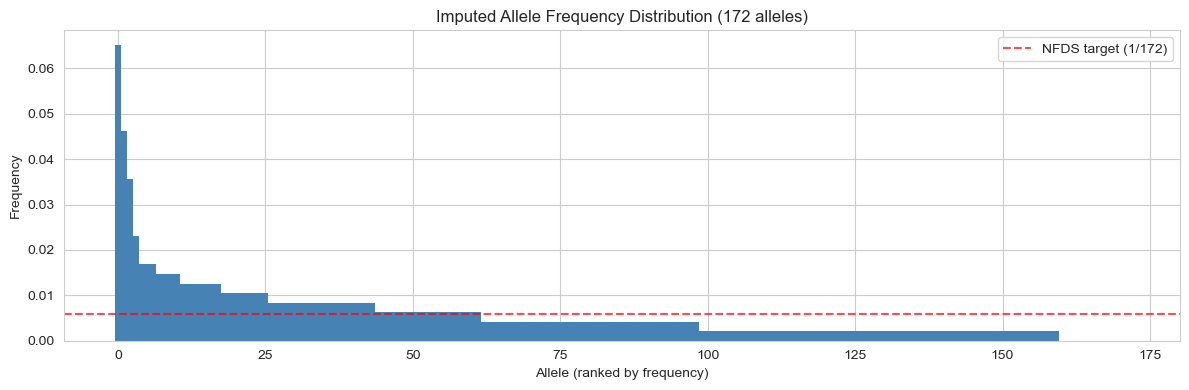

In [13]:
def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies across a population."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))


# Imputed frequencies (from genotypes, 4 allele copies per individual)
imputed_freqs = allele_frequencies(population_genotypes, allele_pool)

# Naive presence/absence frequencies (from genotype matrix, treating each allele as 0/1)
naive_counts = genotypes_df[allele_columns].sum(axis=0)
naive_total = naive_counts.sum()
naive_freqs = {name_to_id[a]: naive_counts[a] / naive_total for a in allele_columns}

# Compare
print(f"Imputed frequencies: {sum(imputed_freqs.values()):.4f} (sum)")
print(f"Naive frequencies: {sum(naive_freqs.values()):.4f} (sum)")

# Find alleles with biggest differences between imputed and naive
diffs = []
for a_id in allele_pool:
    imp = imputed_freqs.get(a_id, 0)
    nav = naive_freqs.get(a_id, 0)
    diffs.append({"allele_id": a_id, "allele_name": id_to_name[a_id],
                  "imputed": imp, "naive": nav, "diff": imp - nav})

diff_df = pd.DataFrame(diffs).sort_values("diff", key=abs, ascending=False)
print(f"\nTop 10 alleles with largest frequency difference (imputed vs naive):")
print(diff_df.head(10).to_string(index=False, float_format="{:.4f}".format))

# Plot imputed frequency distribution
freq_vals = sorted(imputed_freqs.values(), reverse=True)
target = 1.0 / len(allele_pool)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(freq_vals)), freq_vals, color="steelblue", edgecolor="none", width=1.0)
ax.axhline(y=target, color="red", linestyle="--", alpha=0.7, label=f"NFDS target (1/{len(allele_pool)})")
ax.set_xlabel("Allele (ranked by frequency)")
ax.set_ylabel("Frequency")
ax.set_title("Imputed Allele Frequency Distribution (172 alleles)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Population Group Analysis

Examine allele frequencies by library/population group.

Core alleles (in 2+ individuals): 46
Groups: ['Library001', 'Library002', 'Library003', 'Library004', 'Library005', 'Other']



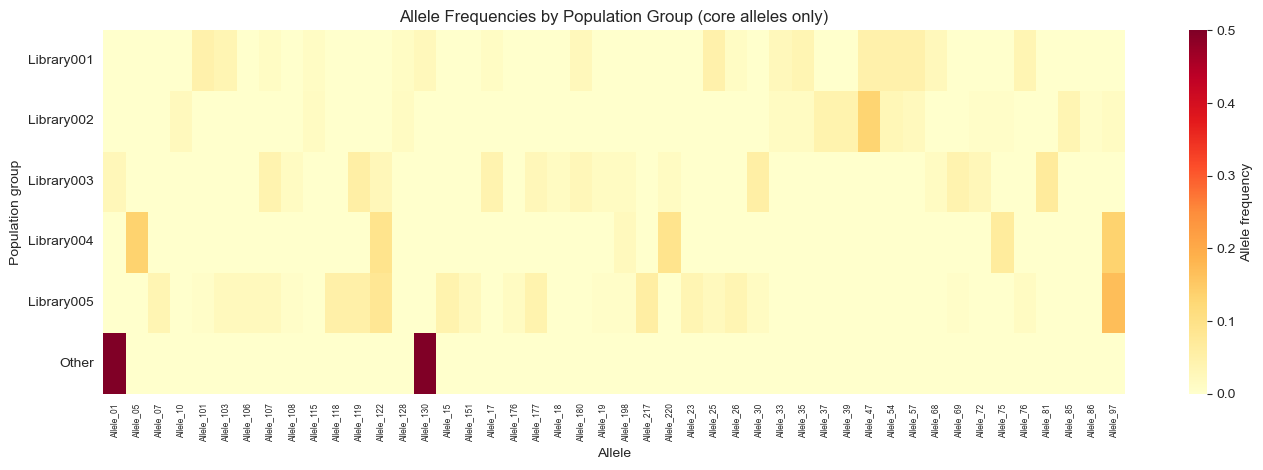

In [14]:
# Build per-group populations
group_populations = {}
for ind_name, genotype in population_real:
    group = get_population_group(ind_name)
    if group not in group_populations:
        group_populations[group] = []
    group_populations[group].append(genotype)

# Find alleles that appear in 2+ individuals (core alleles) for heatmap
core_allele_ids = [name_to_id[a] for a in allele_columns if allele_prevalence[a] >= 2]
core_allele_ids = sorted(core_allele_ids)

print(f"Core alleles (in 2+ individuals): {len(core_allele_ids)}")
print(f"Groups: {sorted(group_populations.keys())}")
print()

# Build group x core-allele frequency matrix
groups_sorted = sorted(group_populations.keys())
freq_matrix = np.zeros((len(groups_sorted), len(core_allele_ids)))

for gi, group in enumerate(groups_sorted):
    grp_freqs = allele_frequencies(group_populations[group], allele_pool)
    for ai, a_id in enumerate(core_allele_ids):
        freq_matrix[gi, ai] = grp_freqs.get(a_id, 0.0)

# Heatmap
fig, ax = plt.subplots(figsize=(max(14, len(core_allele_ids) * 0.2), max(4, len(groups_sorted) * 0.8)))
sns.heatmap(
    freq_matrix,
    xticklabels=[id_to_name[a] for a in core_allele_ids],
    yticklabels=groups_sorted,
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Allele frequency"},
)
ax.set_xlabel("Allele")
ax.set_ylabel("Population group")
ax.set_title("Allele Frequencies by Population Group (core alleles only)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

## 14. Data Quality Summary

In [15]:
# Build summary table
n_single_read_calls = (reads_per_allele_call == 1).sum()

summary_data = {
    "Metric": [
        "Total individuals",
        "Total distinct alleles",
        "Singleton alleles (1 individual)",
        "Core alleles (2+ individuals)",
        "Total read rows",
        "Single-read allele calls",
        "Individuals with 1 allele",
        "Individuals with 2 alleles",
        "Individuals with 3 alleles",
        "Individuals with 4 alleles (ideal)",
        "Individuals with >4 alleles",
        "High confidence genotypes",
        "Medium confidence genotypes",
        "Low confidence genotypes",
    ],
    "Value": [
        len(individuals_geno),
        n_total_alleles,
        n_singletons,
        n_total_alleles - n_singletons,
        len(allele_table),
        int(n_single_read_calls),
        int(breakdown.get(1, 0)),
        int(breakdown.get(2, 0)),
        int(breakdown.get(3, 0)),
        int(breakdown.get(4, 0)),
        int(sum(breakdown.get(i, 0) for i in breakdown.index if i > 4)),
        int((meta_df["confidence"] == "high").sum()),
        int((meta_df["confidence"] == "medium").sum()),
        int((meta_df["confidence"] == "low").sum()),
    ],
}

summary_table = pd.DataFrame(summary_data)
print("Data Quality Summary")
print("=" * 50)
print(summary_table.to_string(index=False))

Data Quality Summary
                            Metric  Value
                 Total individuals    119
            Total distinct alleles    172
  Singleton alleles (1 individual)    126
     Core alleles (2+ individuals)     46
                   Total read rows    648
          Single-read allele calls     89
         Individuals with 1 allele     35
        Individuals with 2 alleles     53
        Individuals with 3 alleles     19
Individuals with 4 alleles (ideal)      6
       Individuals with >4 alleles      6
         High confidence genotypes      6
       Medium confidence genotypes     19
          Low confidence genotypes     94


## 15. Export Data

Save imputed population data for use in downstream notebooks (especially `06_real_analysis.ipynb`).

In [16]:
# Package everything for export
export_data = {
    "population": population_genotypes,
    "individual_names": individual_names,
    "allele_pool": allele_pool,
    "name_to_id": name_to_id,
    "id_to_name": id_to_name,
    "metadata": individual_metadata,
    "pop_groups": dict(pop_groups),
    "core_allele_ids": core_allele_ids,
}

# Save pickle
pkl_path = os.path.join(DATA_DIR, "imputed_population.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(export_data, f)
print(f"Saved pickle: {pkl_path}")

# Save TSV of imputed genotypes
tsv_rows = []
for ind_name, genotype in population_real:
    allele_names = [id_to_name[a] for a in genotype]
    tsv_rows.append({
        "Individual": ind_name,
        "Allele_1": allele_names[0],
        "Allele_2": allele_names[1],
        "Allele_3": allele_names[2],
        "Allele_4": allele_names[3],
        "Allele_ID_1": genotype[0],
        "Allele_ID_2": genotype[1],
        "Allele_ID_3": genotype[2],
        "Allele_ID_4": genotype[3],
        "Group": get_population_group(ind_name),
    })

tsv_df = pd.DataFrame(tsv_rows)
tsv_path = os.path.join(DATA_DIR, "imputed_genotypes.tsv")
tsv_df.to_csv(tsv_path, sep="\t", index=False)
print(f"Saved TSV: {tsv_path}")
print(f"\n{tsv_df.head(10).to_string(index=False)}")

Saved pickle: ../data/imputed_population.pkl
Saved TSV: ../data/imputed_genotypes.tsv

          Individual   Allele_1   Allele_2   Allele_3   Allele_4  Allele_ID_1  Allele_ID_2  Allele_ID_3  Allele_ID_4      Group
          BEA_hybrid  Allele_01  Allele_01 Allele_130 Allele_130            1            1           31           31      Other
Library001_barcode01 Allele_130 Allele_130 Allele_171 Allele_230           31           31           74          136 Library001
Library001_barcode02 Allele_180 Allele_180  Allele_25  Allele_25           84           84          137          137 Library001
Library001_barcode04  Allele_32  Allele_32  Allele_35  Allele_38          141          141          143          145 Library001
Library001_barcode05  Allele_54  Allele_54  Allele_54  Allele_54          149          149          149          149 Library001
Library001_barcode06  Allele_57  Allele_57  Allele_57  Allele_57          151          151          151          151 Library001
Library001_barcod

In [17]:
def load_real_population(data_dir=None):
    """Convenience function to load imputed population data.

    Returns
    -------
    dict with keys:
        population : list[tuple] - imputed genotypes
        individual_names : list[str] - individual names (parallel to population)
        allele_pool : list[int] - all allele IDs
        name_to_id : dict - allele name to integer ID
        id_to_name : dict - integer ID to allele name
        metadata : list[dict] - imputation metadata per individual
        pop_groups : dict - individual name to population group
        core_allele_ids : list[int] - alleles present in 2+ individuals
    """
    if data_dir is None:
        data_dir = os.path.join("..", "data")
    pkl_path = os.path.join(data_dir, "imputed_population.pkl")
    with open(pkl_path, "rb") as f:
        return pickle.load(f)


# Verify round-trip
loaded = load_real_population(DATA_DIR)
assert loaded["population"] == population_genotypes
assert loaded["allele_pool"] == allele_pool
print(f"Round-trip verification passed: {len(loaded['population'])} genotypes, {len(loaded['allele_pool'])} alleles")

Round-trip verification passed: 119 genotypes, 172 alleles
